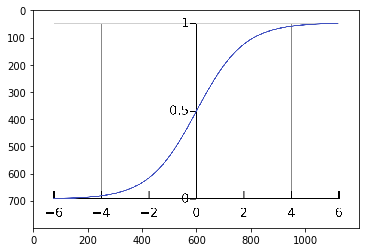

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
image = mpimg.imread("images/logistic.png")
plt.imshow(image)
plt.show()

# Error Function

$z = w^Tx$

$h = σ(z)$

$σ(z) = \frac{1}{1+exp(z)}$

$$P(y=1|x)= \frac{1}{1+exp(-w^Tx)}$$

$$P(y=0|x)= 1- P(y=1|x) = 1- \frac{1}{1+exp(-w^Tx)} $$

Üstteki iki ifadenin genel formu;
$$ 𝑃(𝑦|𝑥) = 𝑃(𝑦=1|𝑥) 𝑃(𝑦=0|𝑥) $$

$$ 𝑃(𝑦|𝑥) = h^y (1 − h)^{(1−y)} $$

$$ \log 𝑃(𝑦|𝑥) = \log(h^y (1 − h)^{(1−y)}) $$

$$ \log 𝑃(𝑦|𝑥) = \log h^y + \log (1 − h)^{(1−y)} $$

Loss function
$$ 𝑦 \log ℎ + (1 − 𝑦) \log(1 − ℎ)$$ 

Error function
$$ 𝐽(𝑤) = \frac{1}{m}Σ[-𝑦 \log ℎ - (1 − 𝑦) \log(1 − ℎ)] $$


# Gradient Descent (Optimization)

Gradient Descent: Chain Rule
$$ \frac{\partial J(w)}{\partial w} = \frac{\partial J(w)}{\partial h} \frac{\partial h}{\partial z} \frac{\partial z}{\partial w} $$

$$\frac{\partial J(w)}{\partial h} = \frac{1}{m} (-\frac{y}{h} + \frac{1-y}{1-h}) $$

$$\frac{\partial h}{\partial z} = h (1-h) $$

$$\frac{\partial z}{\partial w} = x $$

$$\frac{\partial J(w)}{\partial w} = \frac{x (h-y)}{m} $$

# Logistic Regression 

[0.66592726 0.09164428 0.4232816 ]
0.9390736763447959
[-0.95028846  4.20794819 -6.97189919]
0.05163356404273611


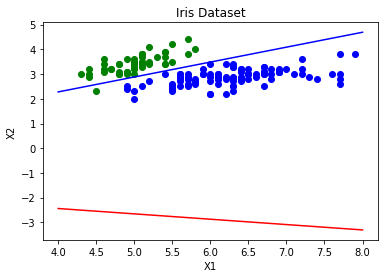

In [13]:
import sklearn.datasets
import matplotlib.pyplot as plt
import numpy as np 
import random

def loadData():
    iris = sklearn.datasets.load_iris()
    X = iris.data[:, :2]
    y = (iris.target != 0) * 1 #binary data
    bias = np.ones((X.shape[0],1))
    X = np.concatenate((bias,X), axis=1)
    #print(iris.target)
    #print(y)
    return X,y

def plotScatter(x,y):
    plt.scatter(x[y == 0][:, 1], x[y == 0][:, 2], color='g', label='0')
    plt.scatter(x[y == 1][:, 1], x[y == 1][:, 2], color='b', label='1')
    plt.title('Iris Dataset')
    plt.xlabel('X1')
    plt.ylabel('X2')
    
def plotModel(w, x, c):
    # init. weights
    x1 = np.linspace(4,8)
    y = -(w[0] + w[1]*x1)/w[2]
    plt.plot(x1,y,c)
    
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def calErr(h, y):
    return (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()


def update_weights(w, x, y, learning_rate, iter_val):
    m = len(y)
    
    for i in range(iter_val):
        z = np.dot(w,x.T)
        h = sigmoid(z)
        gradient_w = np.dot(x.T, (h - y)) / m
        w -= gradient_w*learning_rate
        
    return w

if __name__ == "__main__":
    x,y = loadData()
    plotScatter(x,y)
    
    #w = np.ones(x.shape[1])
    w = np.random.rand(x.shape[1])
    z = np.dot(w,x.T)
    h = sigmoid(z)
    err = calErr(h, y)
    print(w)
    print(err)
    plotModel(w, x,'-r')
    
    w = update_weights(w, x, y, 0.001, 300000)
    
    z = np.dot(w,x.T)
    h = sigmoid(z)
    err = calErr(h, y)
    print(w)
    print(err)
    plotModel(w, x, '-b')